<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

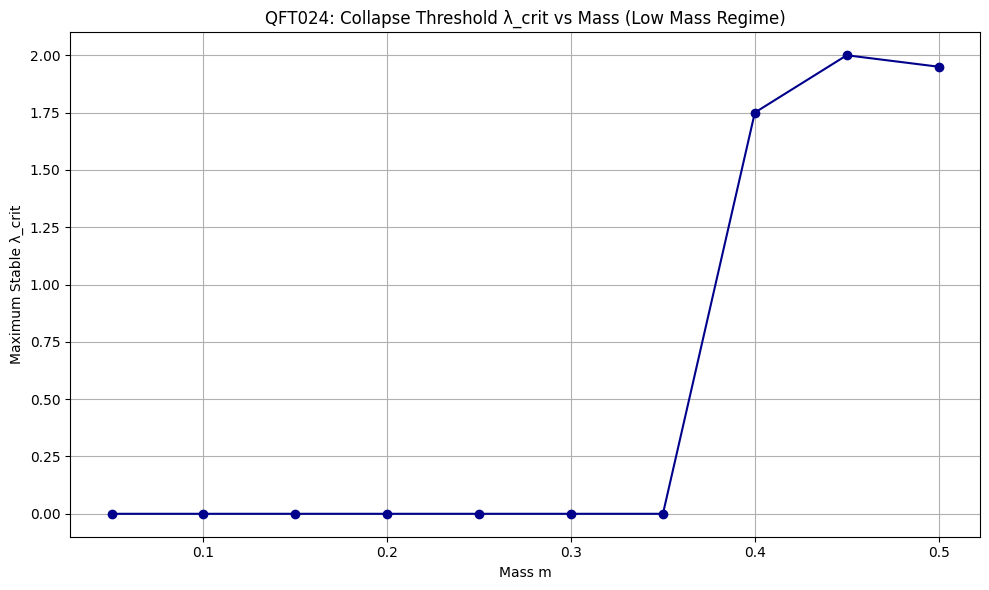

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
mass_values = np.round(np.arange(0.05, 0.55, 0.05), 2)
lambda_values = np.round(np.arange(0.1, 2.05, 0.05), 2)
mu = 0.995  # damping
timesteps = 100
lattice_size = 50

# Stability thresholds
variance_threshold = 0.05
coherence_threshold = 0.1

# Initialize results
lambda_crit_map = {}

# Simulation function
def run_simulation(mass, lam):
    x = np.random.uniform(-1, 1, lattice_size)
    for _ in range(timesteps):
        grad_S = np.gradient(x)
        curv_S = np.gradient(grad_S)
        delta_x = -grad_S + lam * mass * curv_S
        x += mu * delta_x
        x = np.clip(x, -1, 1)
    variance = np.var(x)
    coherence = np.mean(np.abs(np.diff(x)))
    return variance < variance_threshold and coherence < coherence_threshold

# Sweep over mass and lambda
for m in mass_values:
    stable_lambdas = []
    for lam in lambda_values:
        if run_simulation(m, lam):
            stable_lambdas.append(lam)
    lambda_crit_map[m] = max(stable_lambdas) if stable_lambdas else 0

# Plot survival basin
plt.figure(figsize=(10, 6))
plt.plot(list(lambda_crit_map.keys()), list(lambda_crit_map.values()), 'o-', color='darkblue')
plt.title("QFT024: Collapse Threshold λ_crit vs Mass (Low Mass Regime)")
plt.xlabel("Mass m")
plt.ylabel("Maximum Stable λ_crit")
plt.grid(True)
plt.tight_layout()
plt.show()

# Save results
df = pd.DataFrame({
    "Mass": list(lambda_crit_map.keys()),
    "Lambda_crit": list(lambda_crit_map.values())
})
df.to_csv("qft024_lambda_crit_map.csv", index=False)
